# 第33篇｜抽样与中心极限定理

> 这是「数据分析从入门到精通」系列的第 33 篇。概率分布学完了，这篇来聊一个"改变了统计学历史"的定理——中心极限定理。为什么样本够大就能用正态分布？为什么抽样能代表总体？这篇给你讲清楚。

---

嗨，我是小荷～

今天讲一个统计学里最迷人的定理——**中心极限定理（Central Limit Theorem，CLT）**。

它回答了一个很基本的问题：**为什么只需要抽取少量样本，就能了解整个总体？**

这个定理几乎是所有统计推断（置信区间、假设检验）的地基，也是为什么民调、A/B测试可以用几百人代表几百万人的根本原因。

---

## 一、抽样的基本概念

**总体（Population）**：你关心的全部对象（如全国所有用户）
**样本（Sample）**：从总体中抽出的一部分（如随机抽取 1000 个用户）
**参数（Parameter）**：总体的统计量（如总体均值 μ，总体方差 σ²）
**统计量（Statistic）**：样本的统计量（如样本均值 x̄，样本方差 s²）

我们通常**无法观测整个总体**，所以用样本统计量来**估计**总体参数。

---

## 二、抽样分布：样本均值的波动

假设总体均值为 μ，从中抽样 n 个人，计算均值 x̄。**每次抽到的样本不一样，x̄ 也不一样**。

x̄ 本身也是一个随机变量，它有自己的分布，叫**抽样分布**。


总体均值 μ = 30,363
总体标准差 σ = 28,635


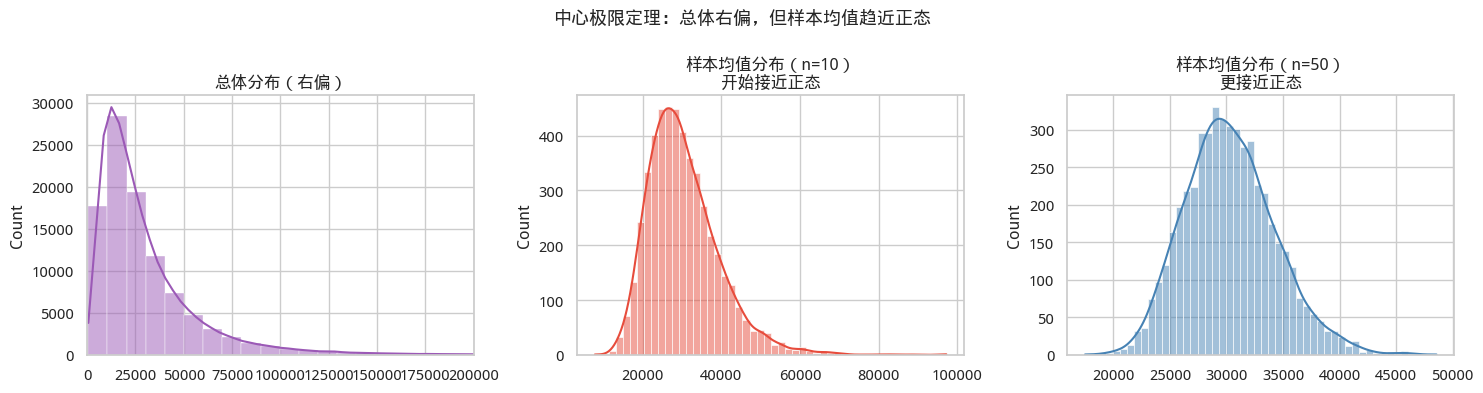


样本均值的均值（n=50）: 30,324（应接近总体均值）
样本均值的标准差（n=50）: 4,000
理论标准误 σ/√n: 4,050


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑

np.random.seed(42)

# 总体：一个右偏分布（收入数据）
population = np.random.lognormal(mean=10, sigma=0.8, size=100000)

print(f"总体均值 μ = {population.mean():,.0f}")
print(f"总体标准差 σ = {population.std():,.0f}")

# 做 5000 次抽样（每次取 n=50），记录每次样本均值
n_samples = 5000
sample_means_n50 = [np.random.choice(population, 50).mean() for _ in range(n_samples)]
sample_means_n10 = [np.random.choice(population, 10).mean() for _ in range(n_samples)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 总体分布（右偏）
sns.histplot(population, bins=80, ax=axes[0], color='#9B59B6', kde=True)
axes[0].set_title('总体分布（右偏）', fontweight='bold')
axes[0].set_xlim(0, 200000)

# 样本均值分布（n=10）
sns.histplot(sample_means_n10, bins=50, ax=axes[1], color='#E74C3C', kde=True)
axes[1].set_title('样本均值分布（n=10）\n开始接近正态', fontweight='bold')

# 样本均值分布（n=50）
sns.histplot(sample_means_n50, bins=50, ax=axes[2], color='steelblue', kde=True)
axes[2].set_title('样本均值分布（n=50）\n更接近正态', fontweight='bold')

plt.suptitle('中心极限定理：总体右偏，但样本均值趋近正态', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n样本均值的均值（n=50）: {np.mean(sample_means_n50):,.0f}（应接近总体均值）")
print(f"样本均值的标准差（n=50）: {np.std(sample_means_n50):,.0f}")
print(f"理论标准误 σ/√n: {population.std()/np.sqrt(50):,.0f}")


**你看到了什么？** 总体是右偏的，但当 n 越大，样本均值的分布越接近正态！这就是中心极限定理。

---

## 三、中心极限定理的精确表述

设总体均值为 μ，方差为 σ²，从中抽取大小为 n 的随机样本，当 n 足够大（一般 n ≥ 30）时：


In [ ]:
样本均值 x̄ ~ N(μ, σ²/n)


即：
- 样本均值的期望 = 总体均值
- 样本均值的标准差（标准误）= σ / √n

**重要推论**：
1. 样本量越大，x̄ 越稳定（标准误越小）
2. **不管总体是什么分布**，只要 n 足够大，x̄ 就近似正态


In [3]:
# 验证标准误 = σ/√n
n_values = [5, 10, 30, 50, 100, 200]
print("n\t标准误（模拟）\t标准误（理论）")
for n in n_values:
    means = [np.random.choice(population, n).mean() for _ in range(2000)]
    sim_se = np.std(means)
    theory_se = population.std() / np.sqrt(n)
    print(f"{n}\t{sim_se:,.0f}\t\t{theory_se:,.0f}")


n	标准误（模拟）	标准误（理论）
5	12,962		12,806
10	9,164		9,055
30	5,256		5,228
50	4,053		4,050
100	2,867		2,864
200	2,011		2,025


---

## 四、标准误（Standard Error）

标准误 SE = σ / √n，是衡量"用样本均值估计总体均值时的不确定性"的指标。

- SE 越小，估计越精准
- 增大 n 是减小 SE 的唯一方式
- SE 随 n 的平方根增大而减小（边际递减）


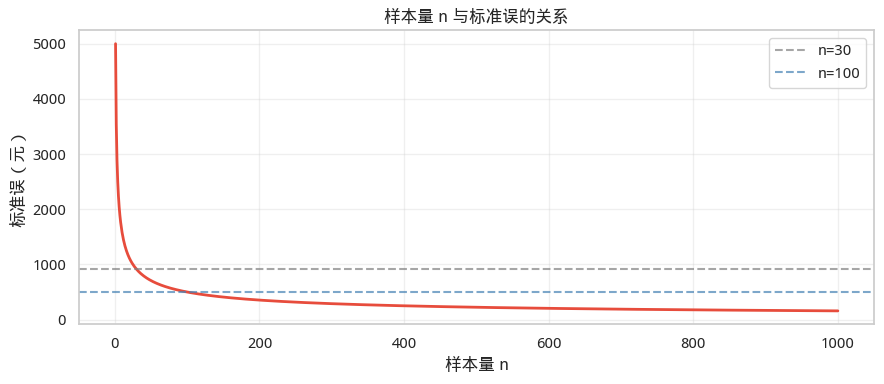

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

sigma = 5000  # 总体标准差（元）
n_values = np.arange(1, 1001)
se_values = sigma / np.sqrt(n_values)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_values, se_values, color='#E74C3C', linewidth=2)
ax.axhline(y=sigma/np.sqrt(30), color='gray', linestyle='--', alpha=0.7, label='n=30')
ax.axhline(y=sigma/np.sqrt(100), color='steelblue', linestyle='--', alpha=0.7, label='n=100')

ax.set_title('样本量 n 与标准误的关系', fontweight='bold')
ax.set_xlabel('样本量 n')
ax.set_ylabel('标准误（元）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 五、实际应用：A/B 测试需要多少样本？

样本量直接决定检验的把握度，来看看怎么算：


In [13]:
from scipy import stats
import numpy as np

# 场景：测试新活动方案是否能提升转化率
# 当前转化率 p0 = 10%，希望检测到 2% 的提升（提升到 12%）
# 显著性水平 α = 0.05，检验效力 1-β = 0.80

p0 = 0.10   # 基准转化率
p1 = 0.12   # 期望提升后的转化率
alpha = 0.05
power = 0.80

# 样本量计算公式
z_alpha = stats.norm.ppf(1 - alpha/2)   # 1.9600 双尾检验 ，（提升或下降都可能），每侧分配 α/2
z_beta  = stats.norm.ppf(power)    # 0.8416

p_bar = (p0 + p1) / 2  # 0.11

numerator = z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * np.sqrt(p0*(1-p0) + p1*(1-p1)) 
# 1.2395 ， H0 下的标准差+ H1 下的标准差
denominator = p1 - p0                 # 0.02
n_required = (numerator / denominator) ** 2  # 因为标准误与 √n 成反比：SE = σ / √n，要使 SE 缩小到能分辨 δ = p1 - p0，就需要 √n = 分子/分母，所以 n = (分子/分母)²。

print(f"A/B 测试每组需要至少 {int(np.ceil(n_required))} 个用户")
print(f"（总计 {int(np.ceil(n_required)) * 2} 个用户）")

A/B 测试每组需要至少 3841 个用户
（总计 7682 个用户）


这就是为什么 A/B 测试不是"随便跑几天就行"——你需要足够的样本量，统计结论才可靠。

---

## 六、📝 小结

| 概念 | 含义 |
|------|------|
| 总体参数 | 真实的、通常未知的总体统计量 |
| 样本统计量 | 从样本计算的，用来估计总体参数 |
| 标准误 SE | σ/√n，衡量样本均值的不确定性 |
| 中心极限定理 | n≥30时，样本均值近似正态 |

**CLT 的意义**：不管数据原来是什么分布，只要样本量够大，就可以用正态分布来做推断。这是所有 t 检验、置信区间、假设检验的基础！

---

## 七、🏋️ 课后练习

1. 模拟实验：从均匀分布 U(0,10) 中反复抽取 n=5, 30, 100 个样本，画出每种情况下 5000 次样本均值的分布，验证 CLT。
2. 某调查样本量 n=400，总体标准差估计为 200 元，计算样本均值的标准误。
3. 如果想把标准误缩小到原来的一半，样本量需要增加多少倍？

In [14]:
# 1. 模拟实验：从均匀分布 U(0,10) 中反复抽取 n=5, 30, 100 个样本，画出每种情况下 5000 次样本均值的分布，验证 CLT。
print("\n【实验设计】")
print("从均匀分布 U(0, 10) 中反复抽取样本")
print("样本量分别为 n = 5, 30, 100")
print("每种情况重复 5000 次，计算样本均值")
print("观察样本均值的分布是否符合正态分布")

# 均匀分布 U(0, 10) 的参数
uniform_low = 0
uniform_high = 10
n_simulations = 5000  # 模拟次数

# 不同样本量
sample_sizes = [5, 30, 100]

# 存储样本均值的数组
sample_means = {}

print("\n【模拟结果】")
for n in sample_sizes:
    # 生成 5000 x n 的随机矩阵，每行是一次抽样
    samples = np.random.uniform(uniform_low, uniform_high, size=(n_simulations, n))
    # 计算每行的均值（即每次抽样的样本均值）
    means = np.mean(samples, axis=1)
    sample_means[n] = means
    
    print(f"\n样本量 n = {n}:")
    print(f"  样本均值的均值: {np.mean(means):.4f} (理论值: 5.0)")
    print(f"  样本均值的标准差: {np.std(means):.4f} (理论值: {10/(np.sqrt(12*n)):.4f})")
    print(f"  样本均值的偏度: {stats.skew(means):.4f} (正态分布偏度≈0)")
    print(f"  样本均值的峰度: {stats.kurtosis(means):.4f} (正态分布峰度≈0)")

# 理论均匀分布的信息
print("\n【理论背景】")
print(f"均匀分布 U(0, 10):")
print(f"  总体均值 μ = (0 + 10) / 2 = 5.0")
print(f"  总体方差 σ² = (10-0)² / 12 = 100/12 ≈ 8.333")
print(f"  总体标准差 σ ≈ 2.887")
print(f"\n根据中心极限定理，样本均值的分布:")
print(f"  期望 E(X̄) = μ = 5.0")
print(f"  标准误 SE = σ / √n")


【实验设计】
从均匀分布 U(0, 10) 中反复抽取样本
样本量分别为 n = 5, 30, 100
每种情况重复 5000 次，计算样本均值
观察样本均值的分布是否符合正态分布

【模拟结果】

样本量 n = 5:
  样本均值的均值: 5.0162 (理论值: 5.0)
  样本均值的标准差: 1.2861 (理论值: 1.2910)
  样本均值的偏度: -0.0164 (正态分布偏度≈0)
  样本均值的峰度: -0.2666 (正态分布峰度≈0)

样本量 n = 30:
  样本均值的均值: 4.9907 (理论值: 5.0)
  样本均值的标准差: 0.5305 (理论值: 0.5270)
  样本均值的偏度: -0.0325 (正态分布偏度≈0)
  样本均值的峰度: 0.0302 (正态分布峰度≈0)

样本量 n = 100:
  样本均值的均值: 5.0065 (理论值: 5.0)
  样本均值的标准差: 0.2897 (理论值: 0.2887)
  样本均值的偏度: -0.0133 (正态分布偏度≈0)
  样本均值的峰度: -0.1255 (正态分布峰度≈0)

【理论背景】
均匀分布 U(0, 10):
  总体均值 μ = (0 + 10) / 2 = 5.0
  总体方差 σ² = (10-0)² / 12 = 100/12 ≈ 8.333
  总体标准差 σ ≈ 2.887

根据中心极限定理，样本均值的分布:
  期望 E(X̄) = μ = 5.0
  标准误 SE = σ / √n


In [15]:
# 2. 某调查样本量 n=400，总体标准差估计为 200 元，计算样本均值的标准误。
# 参数设置
n_survey = 400       # 样本量
sigma_estimate = 200 # 总体标准差估计（元）

# 计算样本均值的标准误
# SE = σ / √n
standard_error = sigma_estimate / np.sqrt(n_survey)

print(f"题目: 调查样本量 n = {n_survey}")
print(f"      总体标准差估计 σ = {sigma_estimate} 元")
print(f"\n计算公式: SE = σ / √n")
print(f"计算过程: SE = {sigma_estimate} / √{n_survey}")
print(f"结果: 样本均值的标准误 = {standard_error:.4f} 元")

print(f"\n【含义解释】")
print(f"这意味着如果多次抽样，样本均值的标准差约为 {standard_error:.2f} 元")
print(f"即我们有约 68% 的置信度相信真实总体均值在")  # 标准正态分布表 P(-1 ≤ Z ≤ 1) = P(Z ≤ 1) - P(Z ≤ -1) = 0.8413 - 0.1587 ≈ 68.27%
print(f"  样本均值 ± {standard_error:.2f} 元 范围内")

题目: 调查样本量 n = 400
      总体标准差估计 σ = 200 元

计算公式: SE = σ / √n
计算过程: SE = 200 / √400
结果: 样本均值的标准误 = 10.0000 元

【含义解释】
这意味着如果多次抽样，样本均值的标准差约为 10.00 元
即我们有约 68% 的置信度相信真实总体均值在
  样本均值 ± 10.00 元 范围内


In [16]:
# 3. 如果想把标准误缩小到原来的一半，样本量需要增加多少倍？
print("【问题分析】")
print("标准误公式: SE = σ / √n")
print("若要将标准误缩小到原来的一半:")
print("  新SE = SE_original / 2")
print("  σ / √(n_new) = σ / (2√n_original)")
print("  √(n_new) = 2√n_original")
print("  n_new = 4 × n_original")

# 原来样本量
n_original = n_survey
# 新的样本量
n_new = 4 * n_original

print(f"\n原样本量 n = {n_original}")
print(f"新样本量 n = {n_original} × 4 = {n_new}")
print(f"\n【结论】需要将样本量增加到原来的 4 倍")

# 验证
se_original = sigma_estimate / np.sqrt(n_original)
se_new = sigma_estimate / np.sqrt(n_new)
print(f"\n验证:")
print(f"  原标准误 SE = {se_original:.4f}")
print(f"  新标准误 SE = {se_new:.4f}")
print(f"  比值 = {se_new/se_original:.4f} ≈ 0.5 (确实是原来的一半)")

【问题分析】
标准误公式: SE = σ / √n
若要将标准误缩小到原来的一半:
  新SE = SE_original / 2
  σ / √(n_new) = σ / (2√n_original)
  √(n_new) = 2√n_original
  n_new = 4 × n_original

原样本量 n = 400
新样本量 n = 400 × 4 = 1600

【结论】需要将样本量增加到原来的 4 倍

验证:
  原标准误 SE = 10.0000
  新标准误 SE = 5.0000
  比值 = 0.5000 ≈ 0.5 (确实是原来的一半)


本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 34 篇：置信区间 — 估计真实均值的范围**
>
> 有了 CLT，我们就可以进行统计推断了。下篇学置信区间——用样本估计总体，我有多大的把握？

---

*跟着小荷，数据分析路上不迷路～*